In [1]:
# YOLO Object Detection

## 1. Install Dependencies
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.5 MB/s eta 0:00:00


In [2]:
## 2. Import Libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
## 3. Load YOLO Model
model = YOLO("yolov8n.pt")

print("YOLO model loaded successfully")

YOLO model loaded successfully



image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 418.7ms
Speed: 14.4ms preprocess, 418.7ms inference, 37.0ms postprocess per image at shape (1, 3, 640, 480)


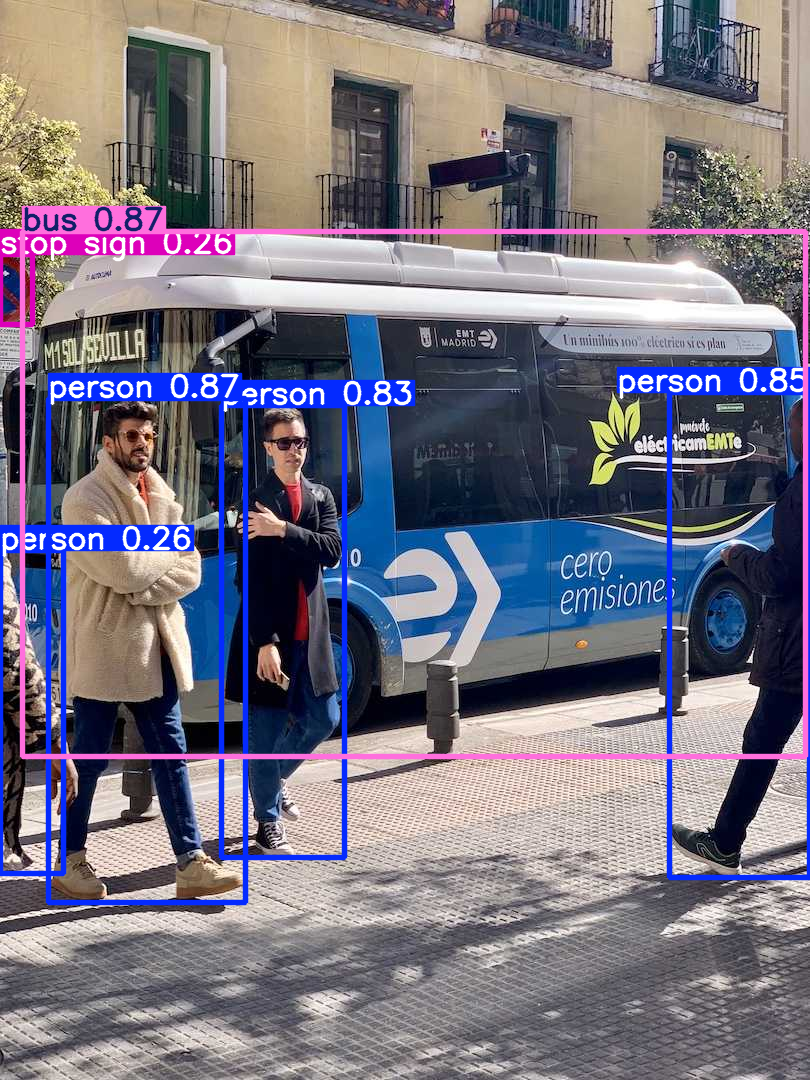

In [4]:
## 4. Run Object Detection
image_url = "https://ultralytics.com/images/bus.jpg"

results = model(image_url)

results[0].show()

In [5]:
## 5. Save Detection Results
results = model(image_url, save=True)

print("Detection results saved successfully")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 270.9ms
Speed: 10.4ms preprocess, 270.9ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Detection results saved successfully


In [6]:
import glob

saved_images = glob.glob("runs/detect/predict/*.jpg")
saved_images

['runs/detect/predict/bus.jpg']

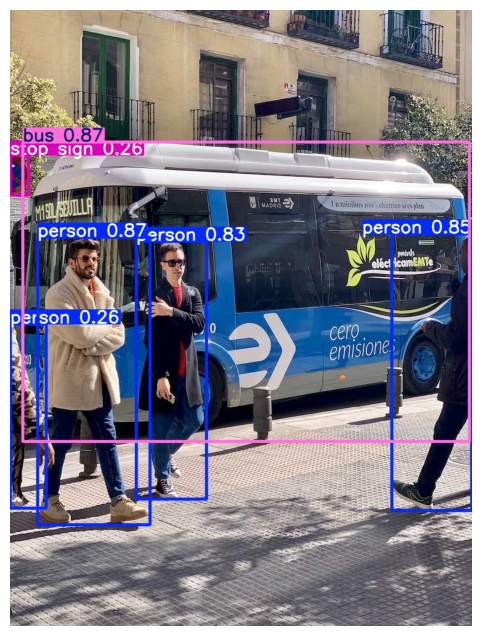

In [7]:
## 6. Display Saved Result
img = Image.open(saved_images[0])

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
## 7. Inspect Detection Results
# Get detected boxes from the first image
boxes = results[0].boxes

print("Number of detected objects:", len(boxes))

for box in boxes:
    class_id = int(box.cls[0])
    confidence = float(box.conf[0])
    class_name = model.names[class_id]

    print(f"Object: {class_name} | Confidence: {confidence:.2f}")

Number of detected objects: 6
Object: bus | Confidence: 0.87
Object: person | Confidence: 0.87
Object: person | Confidence: 0.85
Object: person | Confidence: 0.83
Object: person | Confidence: 0.26
Object: stop sign | Confidence: 0.26


In [9]:
## 8. Run Detection on Multiple Images
image_urls = [
    "https://ultralytics.com/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg"
]

results = model(image_urls, save=True)

print("Detection completed for multiple images")


0: 640x640 4 persons, 1 bus, 221.0ms
1: 640x640 2 persons, 1 tie, 221.0ms
Speed: 6.3ms preprocess, 221.0ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Detection completed for multiple images


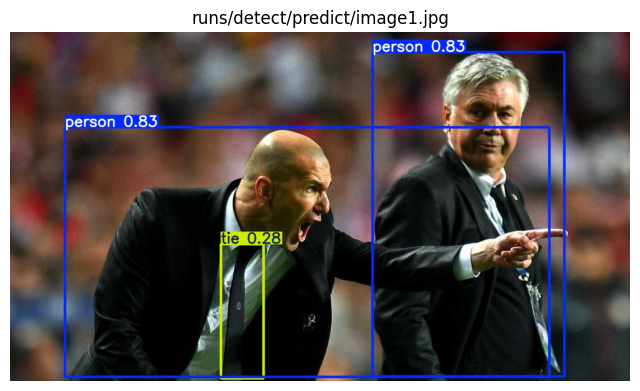

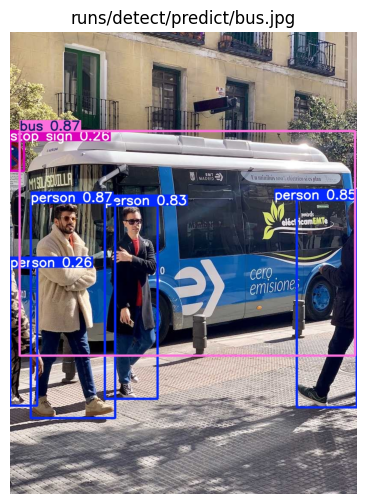

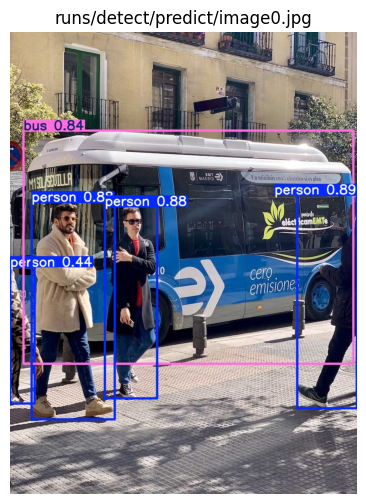

In [10]:
saved_images = glob.glob("runs/detect/predict*/*.jpg")

for img_path in saved_images:
    img = Image.open(img_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path)
    plt.show()

## 9. Project Summary

In this notebook, I implemented object detection using a pretrained YOLOv8 model.

Main steps:
- Installed Ultralytics
- Loaded a pretrained YOLOv8 model
- Ran inference on sample images
- Visualized bounding boxes
- Saved detection results
- Inspected detected classes and confidence scores

This project introduces core Computer Vision concepts such as object detection, bounding boxes, inference, and confidence scores.

## 10. Final Results

The pretrained YOLOv8 model successfully detected multiple objects across sample images.

Detected classes included:

- bus
- person
- stop sign
- tie

The model returned bounding boxes and confidence scores for each detected object, demonstrating a complete object detection inference pipeline.